# EE 559 ML1 : Supervised Learning

# Final Project: credit card default prediction

In [58]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# mount drive to get data
from google.colab import drive
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/2nd Year/Supervised Learning/ML final project/UCI_Credit_Card.csv')
df.head()


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [59]:
# quick info
df.shape
df.info()

# anything missing?
df.isnull().sum()

# summary statistics, for a quick sanity check
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [60]:
# fix education & marriage categorical code
df['EDUCATION'] = df['EDUCATION'].replace({0:4, 5:4, 6:4})
df['MARRIAGE'] = df['MARRIAGE'].replace({0:3})

# remove the ID column cuz not helpful
df = df.drop(columns = ['ID'])

# seperate feature, target
X = df.drop(columns = ['default.payment.next.month'])
y = df['default.payment.next.month']
print(X.shape)

# check class balance
print(y.value_counts())
print(y.value_counts(normalize=True))

(30000, 23)
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
default.payment.next.month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [61]:
# split data in train/validation/test sets
# 70-15-15

np.random.seed(42)
idx = np.random.permutation(len(X)) # to shuffle indices
n = len(X)
train_end = int(0.7 * n) # 70% train
val_end = int(0.85* n)   # 15% val

train_idx = idx[:train_end]       # first 70% shuffled indices
val_idx = idx[train_end:val_end]  # the next 4500
test_idx = idx[val_end:]          # the last 4500

# go from pandas dataframe to numpy array
X_array = X.values
y_array = y.values

X_train, y_train = X_array[train_idx], y_array[train_idx]
X_val, y_val = X_array[val_idx], y_array[val_idx]
X_test, y_test = X_array[test_idx], y_array[test_idx]

In [62]:
# standardization
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_val_s = (X_val - mu) / sigma
X_test_s = (X_test - mu) / sigma

# quick check if see it worked
print("mean of training set: ", X_train_s.mean(axis=0).round(2))
print("std of training set: ", X_train_s.std(axis=0).round(2))

mean of training set:  [ 0.  0.  0.  0. -0.  0.  0. -0.  0.  0. -0. -0.  0. -0.  0.  0. -0.  0.
  0. -0.  0. -0. -0.]
std of training set:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Method 1 - Logistic Regression

In [63]:
# Logistic Regression

def sigmoid(a):
  # squish into (0,1)
  return 1 / (1 + np.exp(-a))

def compute_loss(X, y, w, b, lam):
  N = len(y)
  y_hat = sigmoid(X @ w + b)
  y_hat = np.clip(y_hat, 1e-8, 1 - 1e-8) # wanna avoid log0

  # cross-entropy, padd w small numbre so no inf crash
  ce = -np.sum(y * np.log(y_hat) + (1-y) * np.log(1 - y_hat)) / N

  # L2 penalty
  l2 = (lam/2) * np.sum(w ** 2)

  return ce + l2

def train_logistic(X_train, y_train, X_val, y_val, lam=0.01, lr=0.1, epochs=200, batch_size=256):
  N, D = X_train.shape
  w = np.zeros(D)
  b = 0.0

  train_losses, val_losses = [], [] # track for plotting later

  for epoch in range(epochs): # rmb one epoch = one full pass through the training data
    # mini-batch shuffle, reshuffle each epoch so batches are different each time
    idx = np.random.permutation(N) # random odering
    X_shuf = X_train[idx]          # reorder rows of X
    y_shuf = y_train[idx]          # same reodering for labels

    # mini-batch loop
    for i in range(0, N, batch_size):
      Xb = X_shuf[i:i+batch_size]
      yb = y_shuf[i:i+batch_size]
      nb = len(yb)

      # forward pass: get prediction for this bath
      y_hat = sigmoid(Xb @ w + b)

      # error delE/dela = y_hat - y
      error = y_hat - yb

      # gradients
      dw = (Xb.T @ error) / nb + lam * w # delE/delw = (1/nb) * Xb^T @ err + lambda w
      db = np.mean(error)

      # update
      w -= lr * dw
      b -= lr * db

    # record loss at end of each epoch
    train_loss = compute_loss(X_train, y_train, w, b, lam)
    train_losses.append(train_loss)

    val_loss = compute_loss(X_val, y_val, w, b, lam)
    val_losses.append(val_loss)

    if epoch % 50 == 0:
      print(f"Epoch: {epoch:3d} | train loss: {train_losses[-1]:.2f} | val loss: {val_losses[-1]:.2f}")

  # report the learning results including weights, bias, train loss, val loss
  return w, b, train_losses, val_losses

In [64]:
def predict(X, w, b, threshold=0.5):
  return (sigmoid(X @ w + b) >= threshold).astype(int)

def f1_score(y_true, y_pred):
  # True Positive
  tp = np.sum((y_pred == 1) & (y_true == 1))
  # False Positive
  fp = np.sum((y_pred == 1) & (y_true == 0))
  # False Negative
  fn = np.sum((y_pred == 0) & (y_true == 1))

  # precision: of all predicted defaults, how many were real?
  precision = tp / (tp + fp + 1e-8)
  # recall: of all actual defaults, how many did we catch?
  recall    = tp / (tp + fn + 1e-8)
  # F1: harmonic mean of precision and recall
  f1 = 2 * precision * recall / (precision + recall + 1e-8)

  return precision, recall, f1

In [65]:
# train
w, b, train_losses, val_losses = train_logistic(X_train_s, y_train, X_val_s, y_val,
                                                lam=0.01, lr=0.1, epochs=200, batch_size=256)

# evaluate on val set
y_pred_val = predict(X_val_s, w, b)
acc = np.mean(y_pred_val == y_val)
prec, rec, f1 = f1_score(y_val, y_pred_val)

print(f"\nValidation Accuracy : {acc:.2f}")
print(f"Precision           : {prec:.2f}")
print(f"Recall              : {rec:.2f}")
print(f"F1 Score            : {f1:.2f}")

Epoch:   0 | train loss: 0.48 | val loss: 0.50
Epoch:  50 | train loss: 0.46 | val loss: 0.49
Epoch: 100 | train loss: 0.46 | val loss: 0.49
Epoch: 150 | train loss: 0.46 | val loss: 0.49

Validation Accuracy : 0.81
Precision           : 0.72
Recall              : 0.26
F1 Score            : 0.38


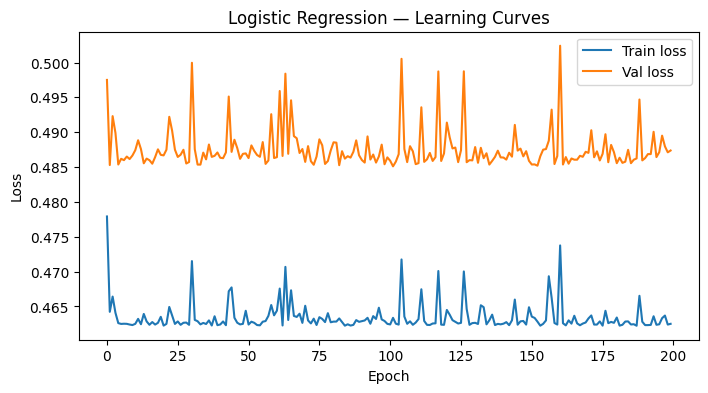

In [66]:
# plot learning curves
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Logistic Regression — Learning Curves')
plt.legend()
plt.show()

wo hyperparameter tuning, we want to change the threshold to see if it gives us better performance. since 0.5 seems to give a prediction result that is biased toward the majority class, so maybe we should lower the threshold - basically flag someone as default risk even if im like 30% confident

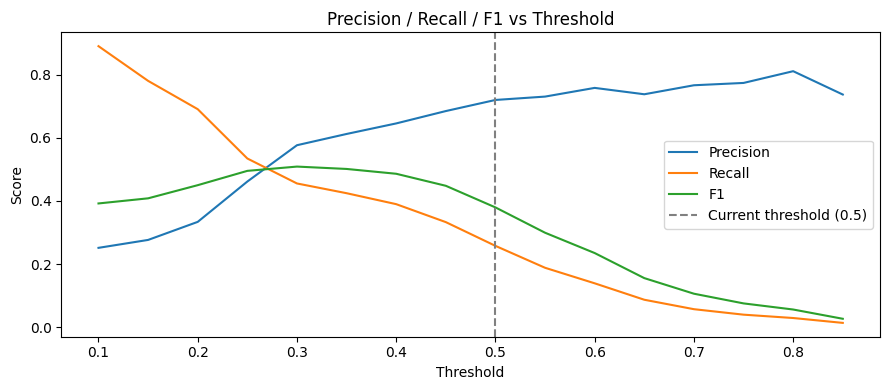

Best threshold by F1 : 0.30
Precision at best    : 0.576
Recall at best       : 0.455
F1 at best           : 0.509


In [67]:
thresholds = np.arange(0.1, 0.9, 0.05)

precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_t = (sigmoid(X_val_s @ w + b) >= t).astype(int)
    p, r, f = f1_score(y_val, y_pred_t)
    precisions.append(p)
    recalls.append(r)
    f1s.append(f)

# plot
plt.figure(figsize=(9,4))
plt.plot(thresholds, precisions, label='Precision')
plt.plot(thresholds, recalls,   label='Recall')
plt.plot(thresholds, f1s,       label='F1')
plt.axvline(x=0.5, color='gray', linestyle='--', label='Current threshold (0.5)')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# find best threshold by F1
best_idx = np.argmax(f1s)
best_t   = thresholds[best_idx]
print(f"Best threshold by F1 : {best_t:.2f}")
print(f"Precision at best    : {precisions[best_idx]:.3f}")
print(f"Recall at best       : {recalls[best_idx]:.3f}")
print(f"F1 at best           : {f1s[best_idx]:.3f}")

# Method 2 - LDA

In [68]:
def train_lda(X_train, y_train):
  classes = [0,1]
  priors, means = {}, {}

  N = len(y_train)

  for c in classes:
    # grab rows that belong to class c
    X_c = X_train[y_train == c]

    # prior: P(0) ~=0.8, P(1) ~= 0.2
    priors[c] = len(X_c) / N

    # mean of each class
    means[c] = X_c.mean(axis=0)

  # shared covar matrix, LDA assume both classes share the same covar
  s = np.zeros((X_train.shape[1], X_train.shape[1]))
  for c in classes:
    Xc = X_train[y_train == c]
    diff = Xc - means[c] # center of data, subtract mean from each row
    s += diff.T @ diff
  s /= (N-len(classes))

  return priors, means, s

In [69]:
def predict_lda(X, priors, means, s):
  s_inv = np.linalg.inv(s)

  scores = []
  for c in [0,1]:
    w_c = s_inv @ means[c]
    b_c = -0.5 * means[c] @ s_inv @ means[c] + np.log(priors[c])
    scores.append(X @ w_c + b_c)

  scores = np.stack(scores, axis=1)
  return np.argmax(scores, axis=1)

In [70]:
# train LDA
priors, means, s_cov = train_lda(X_train_s, y_train)

# predict on validation set
y_pred_lda = predict_lda(X_val_s, priors, means, s_cov)

# evaluate
acc_lda = np.mean(y_pred_lda == y_val)
prec_lda, rec_lda, f1_lda = f1_score(y_val, y_pred_lda)

print(f"LDA Validation Accuracy : {acc_lda:.3f}")
print(f"Precision               : {prec_lda:.3f}")
print(f"Recall                  : {rec_lda:.3f}")
print(f"F1 Score                : {f1_lda:.3f}")

LDA Validation Accuracy : 0.809
Precision               : 0.723
Recall                  : 0.275
F1 Score                : 0.398


now that we have a fundation from above, we can do some hyperparam tunings

In [71]:
# LogReg learning rate tuning

lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
best_lam, best_f1 = None, 0

print(f"{'Lambda:':<10} {'Val F1 (thr=0.3)'}")
print("----------------------------------------------")

for lam in lambdas:
    w_t, b_t, _, _ = train_logistic(
        X_train_s, y_train, X_val_s, y_val,
        lam=lam, lr=0.1, epochs=200, batch_size=256
    )
    y_p = predict(X_val_s, w_t, b_t, threshold=0.3)
    _, _, f1_t = f1_score(y_val, y_p)
    print(f"{lam:<10} {f1_t:>15.3f}")
    if f1_t > best_f1:
        best_f1 = f1_t
        best_lam = lam

print(f"\nBest lambda : {best_lam}")
print(f"Best val F1 : {best_f1:.2f}")

Lambda:    Val F1 (thr=0.3)
----------------------------------------------
Epoch:   0 | train loss: 0.48 | val loss: 0.49
Epoch:  50 | train loss: 0.46 | val loss: 0.48
Epoch: 100 | train loss: 0.46 | val loss: 0.48
Epoch: 150 | train loss: 0.46 | val loss: 0.48
0.0001               0.508
Epoch:   0 | train loss: 0.48 | val loss: 0.49
Epoch:  50 | train loss: 0.46 | val loss: 0.49
Epoch: 100 | train loss: 0.46 | val loss: 0.48
Epoch: 150 | train loss: 0.46 | val loss: 0.49
0.001                0.509
Epoch:   0 | train loss: 0.48 | val loss: 0.49
Epoch:  50 | train loss: 0.46 | val loss: 0.49
Epoch: 100 | train loss: 0.46 | val loss: 0.49
Epoch: 150 | train loss: 0.46 | val loss: 0.49
0.01                 0.500
Epoch:   0 | train loss: 0.49 | val loss: 0.50
Epoch:  50 | train loss: 0.48 | val loss: 0.50
Epoch: 100 | train loss: 0.48 | val loss: 0.50
Epoch: 150 | train loss: 0.48 | val loss: 0.50
0.1                  0.494
Epoch:   0 | train loss: 0.51 | val loss: 0.53
Epoch:  50 | train

In [72]:
# retrain with best lambda
# see if metrics improve
w_best, b_best, train_losses_best, val_losses_best = train_logistic(
    X_train_s, y_train, X_val_s, y_val,
    lam=best_lam, lr=0.1, epochs=200, batch_size=256
)

y_pred_best = predict(X_val_s, w_best, b_best, threshold=0.3)
acc_best = np.mean(y_pred_best == y_val)
prec_best, rec_best, f1_best = f1_score(y_val, y_pred_best)

print("--------------------------------------")
print(f"Tuned LogReg (λ={best_lam}, thr=0.3):")
print(f"Accuracy  : {acc_best:.3f}")
print(f"Precision : {prec_best:.3f}")
print(f"Recall    : {rec_best:.3f}")
print(f"F1        : {f1_best:.3f}")

Epoch:   0 | train loss: 0.48 | val loss: 0.50
Epoch:  50 | train loss: 0.46 | val loss: 0.48
Epoch: 100 | train loss: 0.46 | val loss: 0.48
Epoch: 150 | train loss: 0.46 | val loss: 0.48
--------------------------------------
Tuned LogReg (λ=0.001, thr=0.3):
Accuracy  : 0.794
Precision : 0.566
Recall    : 0.457
F1        : 0.506


In [73]:
# LDA threshold tuning
s_inv_lda = np.linalg.inv(s_cov)

lda_raw_val = (
    (X_val_s @ s_inv_lda @ means[1] - 0.5 * means[1] @ s_inv_lda @ means[1] + np.log(priors[1]))
  - (X_val_s @ s_inv_lda @ means[0] - 0.5 * means[0] @ s_inv_lda @ means[0] + np.log(priors[0]))
)
lda_scores_val = sigmoid(lda_raw_val)

thresholds_lda = np.arange(0.1, 0.9, 0.05)
lda_precs, lda_recs, lda_f1s = [], [], []

for t in thresholds_lda:
    y_p = (lda_scores_val >= t).astype(int)
    p, r, f = f1_score(y_val, y_p)
    lda_precs.append(p)
    lda_recs.append(r)
    lda_f1s.append(f)

best_lda_idx = np.argmax(lda_f1s)
best_lda_t = thresholds_lda[best_lda_idx]
print(f"Best LDA threshold by F1 : {best_lda_t:.2f}")
print(f"Precision at best        : {lda_precs[best_lda_idx]:.3f}")
print(f"Recall at best           : {lda_recs[best_lda_idx]:.3f}")
print(f"F1 at best               : {lda_f1s[best_lda_idx]:.3f}")

Best LDA threshold by F1 : 0.25
Precision at best        : 0.498
Recall at best           : 0.518
F1 at best               : 0.508


In [74]:
# test-set evaluation

# LogReg - method 1
y_pred_test_lr = predict(X_test_s, w_best, b_best, threshold=0.3)
acc_lr_test = np.mean(y_pred_test_lr == y_test)
prec_lr_test, rec_lr_test, f1_lr_test = f1_score(y_test, y_pred_test_lr)

# LDA - method 2

lda_raw_test = (
    (X_test_s @ s_inv_lda @ means[1] - 0.5 * means[1] @ s_inv_lda @ means[1] + np.log(priors[1]))
  - (X_test_s @ s_inv_lda @ means[0] - 0.5 * means[0] @ s_inv_lda @ means[0] + np.log(priors[0]))
)
lda_scores_test = sigmoid(lda_raw_test)
y_pred_test_lda = (lda_scores_test >= best_lda_t).astype(int)

acc_lda_test  = np.mean(y_pred_test_lda == y_test)
prec_lda_test, rec_lda_test, f1_lda_test = f1_score(y_test, y_pred_test_lda)

print("--------- Test Result ---------")
print(f"\nLogistic Regression (λ={best_lam}, t=0.3):")
print(f"Accuracy  : {acc_lr_test:.3f}")
print(f"Precision : {prec_lr_test:.3f}")
print(f"Recall    : {rec_lr_test:.3f}")
print(f"F1        : {f1_lr_test:.3f}")
print(f"\nLDA (t=0.25):")
print(f"Accuracy  : {acc_lda_test:.3f}")
print(f"Precision : {prec_lda_test:.3f}")
print(f"Recall    : {rec_lda_test:.3f}")
print(f"F1        : {f1_lda_test:.3f}")

--------- Test Result ---------

Logistic Regression (λ=0.001, t=0.3):
Accuracy  : 0.794
Precision : 0.541
Recall    : 0.476
F1        : 0.507

LDA (t=0.25):
Accuracy  : 0.764
Precision : 0.473
Recall    : 0.531
F1        : 0.500


wasn't really satisfied with the metrics used to evaluate the results above, and found it hard to balance, so want to introduce another set of metric after some googling and ai search.

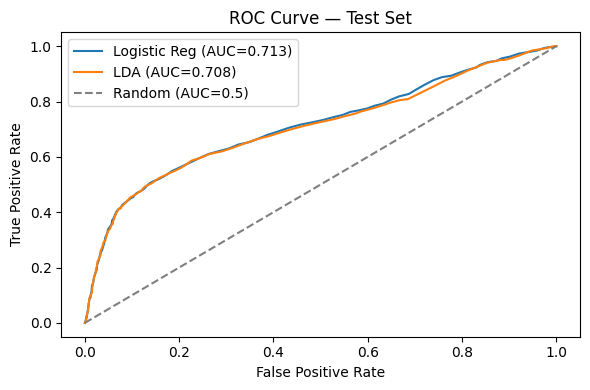

LogReg AUC : 0.713
LDA AUC    : 0.708


In [75]:
def compute_roc_auc(y_true, y_scores):
    thresholds = np.linspace(0, 1, 200)
    tprs, fprs = [], []
    for t in thresholds:
        y_p = (y_scores >= t).astype(int)
        tp = np.sum((y_p==1)&(y_true==1))
        fp = np.sum((y_p==1)&(y_true==0))
        fn = np.sum((y_p==0)&(y_true==1))
        tn = np.sum((y_p==0)&(y_true==0))
        tprs.append(tp/(tp+fn+1e-8))
        fprs.append(fp/(fp+tn+1e-8))
    fprs, tprs = zip(*sorted(zip(fprs, tprs)))
    auc = np.trapezoid(tprs, fprs)
    return fprs, tprs, abs(auc)

# for logistic regression scores
lr_scores = sigmoid(X_test_s @ w_best + b_best)

# for LDA scores
s_inv = np.linalg.inv(s_cov)
w1 = s_inv @ means[1]
b1 = -0.5 * means[1] @ s_inv @ means[1] + np.log(priors[1])
w0 = s_inv @ means[0]
b0 = -0.5 * means[0] @ s_inv @ means[0] + np.log(priors[0])
lda_raw = (X_test_s @ w1 + b1) - (X_test_s @ w0 + b0)
lda_scores = 1 / (1 + np.exp(-lda_raw))
fprs_lr,  tprs_lr,  auc_lr  = compute_roc_auc(y_test, lr_scores)
fprs_lda, tprs_lda, auc_lda = compute_roc_auc(y_test, lda_scores)

plt.figure(figsize=(6,4))
plt.plot(fprs_lr,  tprs_lr,  label=f'Logistic Reg (AUC={auc_lr:.3f})')
plt.plot(fprs_lda, tprs_lda, label=f'LDA (AUC={auc_lda:.3f})')
plt.plot([0,1],[0,1],'--',color='gray',label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Test Set')
plt.legend()
plt.tight_layout()
plt.show()

print(f"LogReg AUC : {auc_lr:.3f}")
print(f"LDA AUC    : {auc_lda:.3f}")